# Experiments vs simulations: Quads design (3dp pla + blue shims) for multiloading source cloaking


## Imports

In [1]:
import matplotlib.pyplot as plt
from matplotlib import patches
from typing import Union
from mechanicalmetamaterialcloaks.plotting import generate_animation
from mechanicalmetamaterialcloaks.utils import save_data, load_data, SolutionData
from problems.quads_dynamic_load_shielding_source_multi_loading import OptimizationProblem
from mechanicalmetamaterialcloaks.plotting import plot_video_frame_field_overlaid, plot_geometry_field_overlaid
from scipy import interpolate
import tqdm

from pathlib import Path
import pandas as pd
from scripts.tracking.utils import smooth_fields_SG
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)  # enable float64 type

plt.style.use(["science", "grid"])
%matplotlib widget

## Paths

In [16]:
# Where to load/save data
data_folder = Path("../../../data/quads_shielding_multi_loading_source_3dp_pla_shims_4_loads")
data_folder_reference = Path("../../../data/quads_shielding_multi_loading_source_3dp_pla_shims_4_loads_reference")
# Where to save plots and animations
out_folder = Path("../../../out/quads_shielding_multi_loading_source_3dp_pla_shims_4_loads")

## Problem info

NOTE: Either define the problem info here or load it from an optimization file.

In [4]:
# NOTE: Units are mm, N, s

# Retrieve design info from optimization data
optimization_filename = f"opt_integrated_with_angle_30_and_length_5_constraints_quads_15x15_amplitude_4.50_loading_rate_2.0_initial_angle_20.0_clamping_corners_True_damping_scaling_1.0"
optimization = OptimizationProblem.from_dict(
    load_data(
        f"{data_folder}/{optimization_filename}.pkl",
    )
)
problem = optimization.forward_problem
# Set up the forward problem to get the geometry
problem.setup()
geometry = problem.cloaked_geometry

# Select the best design
design_values = optimization.design_values[-1]

# Subfolder for videos and tracking data
design_name = optimization_filename

Setup intact case dynamics
Setup the solver of the shielding cloak dynamics


## Experimental video paths


In [5]:
# Experimental videos to be processed - Reference design
video_paths_reference = sorted(
    list(Path(f"{data_folder_reference}/videos").glob("*.mp4")), key=lambda p: p.stem[-3:]
)
# Experimental videos to be processed - Cloaked design
video_paths_cloaked = sorted(
    list(Path(f"{data_folder}/{design_name}/videos").glob("*.mp4")), key=lambda p: p.stem[-3:]
)
video_paths = video_paths_reference + video_paths_cloaked

## Load tracking data


### Reference design

In [6]:
# Find all data files in the dynamic-data folder
tracked_data_paths_reference = sorted(list(Path(
    f"{data_folder_reference}/dynamic-data/tracking_exp/").glob("*.pkl")), key=lambda p: p.stem[-3:])

# Load the tracked data as a dataframe extracting the label, loading angle, voltage, frequency, and trial from the filename
tracked_data_reference = pd.DataFrame({
    "label": [p.stem for p in tracked_data_paths_reference],
    "loading_angle": [float(p.stem.split("_")[4]) for p in tracked_data_paths_reference],
    "voltage": [float(p.stem.split("_")[6][:-2]) for p in tracked_data_paths_reference],
    "frequency": [float(p.stem.split("_")[8][:-2]) for p in tracked_data_paths_reference],
    "trial": [int(p.stem.split("_")[10]) for p in tracked_data_paths_reference],
    "video_path": video_paths_reference,
    "data": [SolutionData(**load_data(p)) for p in tracked_data_paths_reference],
})

# Smooth tracking data
tracked_data_reference.data = tracked_data_reference.apply(
    lambda row: row.data._replace(fields=smooth_fields_SG(
        row.data.fields, window_length=[[20, 20, 30], [20, 20, 30]], polyorder=2)),
    axis=1,
)

### Cloaked design

In [7]:
# Find all data files in the dynamic-data folder
tracked_data_paths = sorted(list(Path(f"{data_folder}/{design_name}/dynamic-data/tracking_exp/").glob("*.pkl")), key=lambda p: p.stem[-3:])

# Load the tracked data as a dataframe extracting the label, loading angle, voltage, frequency, and trial from the filename
tracked_data_cloaked = pd.DataFrame({
    "label": [p.stem for p in tracked_data_paths],
    "loading_angle": [float(p.stem.split("_")[4]) for p in tracked_data_paths],
    "voltage": [float(p.stem.split("_")[6][:-2]) for p in tracked_data_paths],
    "frequency": [float(p.stem.split("_")[8][:-2]) for p in tracked_data_paths],
    "trial": [int(p.stem.split("_")[10]) for p in tracked_data_paths],
    "video_path": video_paths_cloaked,
    "data": [SolutionData(**load_data(p)) for p in tracked_data_paths],
})

# Smooth tracking data
tracked_data_cloaked.data = tracked_data_cloaked.apply(
    lambda row: row.data._replace(fields=smooth_fields_SG(
        row.data.fields, window_length=[[20, 20, 30], [20, 20, 30]], polyorder=2)),
    axis=1,
)

### Concatenate dataframes

In [8]:
tracked_data = pd.concat([tracked_data_reference, tracked_data_cloaked], ignore_index=True)

## Solve forward simulation with experimental input

In [8]:
# # NOTE: Filter experiments that we want to simulate
# tracked_data_to_simulate = tracked_data

# for row in tracked_data_to_simulate.itertuples():
#     # Interpolate the shaker input to the simulation timepoints
#     def excited_blocks_fn(t):
#         return jnp.array([
#             jnp.interp(t, row.data.timepoints - row.data.timepoints[0],
#                         row.data.fields[:, 0, problem.mgIDs_excited_blocks[0], 0])+1e-14,  # x
#             jnp.interp(t, row.data.timepoints - row.data.timepoints[0],
#                         row.data.fields[:, 0, problem.mgIDs_excited_blocks[0], 1])+1e-14,  # y
#             jnp.interp(t, row.data.timepoints - row.data.timepoints[0],
#                         row.data.fields[:, 0, problem.mgIDs_excited_blocks[0], 2])+1e-14,  # theta
#         ])
#     # Setup the problem
#     problem.simulation_time = row.data.timepoints[-1] - row.data.timepoints[0]
#     problem.n_timepoints = len(row.data.timepoints)
#     problem.setup(excited_blocks_fn=excited_blocks_fn)
#     # Solve the problem
#     solution_data = problem.solve(
#         optimization.design_values[-1] if "cloaked_shielding" in row.label else optimization.design_values[0],
#         # The following params are ignored as we are using the excited_blocks_fn
#         optimization.forward_input.amplitude[0],
#         optimization.forward_input.loading_rate[0],
#         optimization.forward_input.loading_angle[0],
#     )
#     # Save the solution
#     out_path = f"{data_folder}/{design_name}/dynamic-data/simulation_exp/{row.video_path.stem}.pkl" if "cloaked_shielding" in row.label else f"{data_folder_reference}/dynamic-data/simulation_exp/{row.video_path.stem}.pkl"
#     save_data(
#         out_path,
#         solution_data._asdict()
#     )

## Load simulation data


### Reference design

In [9]:
simulation_data_paths = sorted(list(Path(
    f"{data_folder_reference}/dynamic-data/simulation_exp/").glob("*.pkl")), key=lambda p: p.stem[-3:])

# Load the simulation data as a dataframe extracting the label, loading angle, voltage, frequency, and trial from the filename
simulation_data_reference = pd.DataFrame({
    "label": [p.stem for p in simulation_data_paths],
    "loading_angle": [float(p.stem.split("_")[4]) for p in simulation_data_paths],
    "voltage": [float(p.stem.split("_")[6][:-2]) for p in simulation_data_paths],
    "frequency": [float(p.stem.split("_")[8][:-2]) for p in simulation_data_paths],
    "trial": [int(p.stem.split("_")[10]) for p in simulation_data_paths],
    # "video_path": video_paths_reference,
    "data": [SolutionData(**load_data(p)) for p in simulation_data_paths],
})

### Cloaked design

In [10]:
simulation_data_paths = sorted(list(Path(
    f"{data_folder}/{design_name}/dynamic-data/simulation_exp/").glob("*.pkl")), key=lambda p: p.stem[-3:])

# Load the simulation data as a dataframe extracting the label, loading angle, voltage, frequency, and trial from the filename
simulation_data_cloaked = pd.DataFrame({
    "label": [p.stem for p in simulation_data_paths],
    "loading_angle": [float(p.stem.split("_")[4]) for p in simulation_data_paths],
    "voltage": [float(p.stem.split("_")[6][:-2]) for p in simulation_data_paths],
    "frequency": [float(p.stem.split("_")[8][:-2]) for p in simulation_data_paths],
    "trial": [int(p.stem.split("_")[10]) for p in simulation_data_paths],
    # "video_path": video_paths_cloaked,
    "data": [SolutionData(**load_data(p)) for p in simulation_data_paths],
})

### Concatenate dataframes

In [11]:
simulation_data = pd.concat([simulation_data_reference, simulation_data_cloaked], ignore_index=True)

## Dataframe for comparison

In [12]:
# Create a dataframe to compare the simulation and experimental data
comparison_data = tracked_data.copy()
comparison_data = comparison_data.rename(columns={"data": "tracked_data"})
# Merge the simulation and experimental dataframes
comparison_data = comparison_data.merge(
    simulation_data,
    on=["label", "loading_angle", "voltage", "frequency", "trial"],
    how="left",
)
comparison_data = comparison_data.rename(columns={"data": "simulation_data"})
comparison_data.head()

,label,loading_angle,voltage,frequency,trial,video_path,tracked_data,simulation_data
0,reference_shielding_loading_angle_135.0_voltag...,135.0,65.0,2.0,1,../../../data/quads_shielding_multi_loading_so...,"([[-4.116898793059674e-16, 3.0876740947947556e...","([[-4.116898793059674e-16, 3.0876740947947556e..."
1,reference_shielding_loading_angle_135.0_voltag...,135.0,70.0,2.0,1,../../../data/quads_shielding_multi_loading_so...,"([[-4.116898793059674e-16, 3.0876740947947556e...","([[-4.116898793059674e-16, 3.0876740947947556e..."
2,reference_shielding_loading_angle_135.0_voltag...,135.0,75.0,2.0,1,../../../data/quads_shielding_multi_loading_so...,"([[-4.116898793059674e-16, 3.0876740947947556e...","([[-4.116898793059674e-16, 3.0876740947947556e..."
3,reference_shielding_loading_angle_135.0_voltag...,135.0,65.0,2.0,2,../../../data/quads_shielding_multi_loading_so...,"([[-4.116898793059674e-16, 3.0876740947947556e...","([[-4.116898793059674e-16, 3.0876740947947556e..."
4,reference_shielding_loading_angle_135.0_voltag...,135.0,70.0,2.0,2,../../../data/quads_shielding_multi_loading_so...,"([[-4.116898793059674e-16, 3.0876740947947556e...","([[-4.116898793059674e-16, 3.0876740947947556e..."


## Plot deformation fields

### Helper functions

In [13]:
def value_to_idx(x, linspace_array):
    """Return the index in the linspace_array corresponding to the value x."""
    return int(
        jnp.clip(
            (x-linspace_array[0])/(linspace_array[-1] -
                                   linspace_array[0])*(len(linspace_array) - 1),
            0,
            len(linspace_array) - 1,
        )
    )

In [14]:
def plot_snapshot_experiment(
        df_row: pd.Series,
        field: str,
        time: float,
        field_values = None,
        cmap="inferno",
        alpha_overlay=0.8,
        vlim=None,
        figsize=(4, 4),
        ax=None,):
    """Plot a snapshot of the experiment."""

    vmin, vmax = vlim if vlim is not None else (None, None)
    timepoint = value_to_idx(time, df_row.tracked_data.timepoints)
    fig, axes = plot_video_frame_field_overlaid(
        video_filename=df_row.video_path,
        solution_data=df_row.tracked_data,
        field=field,
        field_values=field_values,
        frame_number=timepoint,
        timepoint=timepoint,
        calib_xy=df_row.calib_xy,
        ROI_X=df_row.ROI_X,
        ROI_Y=df_row.ROI_Y,
        shift_px=df_row.shift_px,
        alpha_overlay=alpha_overlay,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        figsize=figsize,
        ax=ax,
    )
    return fig, axes


def plot_snapshot_simulation(
        solution_data: SolutionData,
        field: str,
        time: float,
        field_values=None,
        cmap="inferno",
        figsize=(4, 4),
        xlim=None,
        ylim=None,
        vlim=None,
        ax=None,):
    """Plot a snapshot of the simulation."""

    timepoint = value_to_idx(time, solution_data.timepoints)
    fig, axes = plot_geometry_field_overlaid(
        data=solution_data,
        field=field,
        timepoint=timepoint,
        field_values=field_values,
        deformed=True,
        cmap=cmap,
        xlim=xlim,
        ylim=ylim,
        vlim=vlim,
        colorbar=False,
        figsize=figsize,
        axis=False,
        ax=ax,
    )
    return fig, axes


def resample_simulation_data(data: SolutionData, n_samples: int = 400):
    """Resample simulation data to match the experimental data (i.e. linear loading/unloading ramp)."""
    normalized_applied_displacement = problem.applied_displacement(
        data.timepoints/data.timepoints[-1], 1., 1.)
    interpolated_fields_loading = interpolate.make_interp_spline(
        x=0.5*normalized_applied_displacement,
        y=data.fields,
        k=3,
        axis=0,
    )

    def interpolated_fields_loading_unloading(t):
        return interpolated_fields_loading(-jnp.abs(t-0.5)+0.5)

    normalized_timepoints = jnp.linspace(0, 1, n_samples)
    return data._replace(
        fields=interpolated_fields_loading_unloading(
            normalized_timepoints
        ),
        timepoints=normalized_timepoints,
    )

### Experiments

In [15]:
# Plotting parameters for each experiment i.e. each row of the tracked_data dataframe
plot_params = dict(
    calib_xy=[(14*15./543, 14*15./543)]*comparison_data.shape[0],
    ROI_X=[(64, 714)]*comparison_data.shape[0],
    ROI_Y=[(251, 901)]*comparison_data.shape[0],
    shift_px=[(58, 50)]*(comparison_data.shape[0]//2) + [(52, 55)]*(comparison_data.shape[0]//2),
)
# Add plot params to the tracked_data dataframe
for key, value in plot_params.items():
    comparison_data[key] = value

selected_experiments = comparison_data[
    (comparison_data.trial == 1) &
    (comparison_data.loading_angle == 45.) &
    ((comparison_data.voltage == 70.) | (comparison_data.voltage == 55.))
]
# selected_experiments

#### Displacement over time

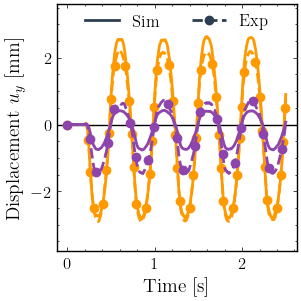

In [17]:
reference_shielding_data = selected_experiments[selected_experiments.label.str.contains("reference_shielding")].iloc[0]
cloaked_shielding_data = selected_experiments[selected_experiments.label.str.contains("cloaked_shielding")].iloc[0]

block_id = -8
time_range = (0, 2.5)  # seconds

# Plot displacement over time of the selected block
plt.close("all")
fig, ax = plt.subplots(figsize=(3, 3), constrained_layout=True)
# Experimental data
ax.plot(
    reference_shielding_data.tracked_data.timepoints[
        (reference_shielding_data.tracked_data.timepoints <= time_range[1]) &
        (reference_shielding_data.tracked_data.timepoints >= time_range[0])
    ],
    reference_shielding_data.tracked_data.fields[
        (reference_shielding_data.tracked_data.timepoints <= time_range[1]) &
        (reference_shielding_data.tracked_data.timepoints >= time_range[0]),
        0,
        block_id,
        1,
    ],
    label="Altered",
    color="#ff9900",
    lw=2, ls="--", marker="o", markevery=0.1, markersize=6,
)
ax.plot(
    cloaked_shielding_data.tracked_data.timepoints[
        (cloaked_shielding_data.tracked_data.timepoints <= time_range[1]) &
        (cloaked_shielding_data.tracked_data.timepoints >= time_range[0])
    ],
    cloaked_shielding_data.tracked_data.fields[
        (cloaked_shielding_data.tracked_data.timepoints <= time_range[1]) &
        (cloaked_shielding_data.tracked_data.timepoints >= time_range[0]),
        0,
        block_id,
        1,
    ],
    label="Cloaked",
    color="#8e44ad",
    lw=2, ls="--", marker="o", markevery=0.1, markersize=6,
    zorder=10,
)
# Simulation data
ax.plot(
    reference_shielding_data.simulation_data.timepoints[
        (reference_shielding_data.simulation_data.timepoints <= time_range[1]) &
        (reference_shielding_data.simulation_data.timepoints >= time_range[0])
    ],
    reference_shielding_data.simulation_data.fields[
        (reference_shielding_data.simulation_data.timepoints <= time_range[1]) &
        (reference_shielding_data.simulation_data.timepoints >= time_range[0]),
        0,
        block_id,
        1,
    ],
    label="Altered - Sim",
    color="#ff9900",
    lw=2,
)
ax.plot(
    cloaked_shielding_data.simulation_data.timepoints[
        (cloaked_shielding_data.simulation_data.timepoints <= time_range[1]) &
        (cloaked_shielding_data.simulation_data.timepoints >= time_range[0])
    ],
    cloaked_shielding_data.simulation_data.fields[
        (cloaked_shielding_data.simulation_data.timepoints <= time_range[1]) &
        (cloaked_shielding_data.simulation_data.timepoints >= time_range[0]),
        0,
        block_id,
        1,
    ],
    label="Cloaked - Sim",
    color="#8e44ad",
    lw=2,
    zorder=10,
)
ax.set_ylim(-3.8, 3.6)
ax.set_xlabel("Time [s]", fontsize=14)
ax.set_ylabel("Displacement $u_y$ [mm]", fontsize=14)
ax.axhline(y=0, color="black", lw=1, zorder=0)
ax.tick_params(labelsize=12)
# Spines 1pt width
for spine in ax.spines.values():
    spine.set_linewidth(1)
# ax.legend(fontsize=12, framealpha=0.9, loc="lower left")
# Create custom legend
lines = [
    plt.Line2D([0], [0], color="#2c3e50", lw=2, label="Sim"),
    plt.Line2D([0], [0], color="#2c3e50", lw=2, ls="--", marker="o", markevery=0.1, markersize=6, label="Exp"),
]
ax.legend(
    handles=lines,
    fontsize=12,
    framealpha=0.8,
    frameon=False,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.02),
)
ax.grid(False)
out_path = out_folder / design_name / f"displacement_vs_time_loading_angle_{reference_shielding_data.loading_angle:.0f}deg.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(str(out_path), dpi=300, bbox_inches="tight")

#### Snapshots

In [19]:
pretrigger_time = 64/300  # 64 frames at 300 fps
loading_rate = 2.  # Hz
selected_timepoints = pretrigger_time + (4+jnp.array([0., 0.25, 0.5, 0.75]))/loading_rate


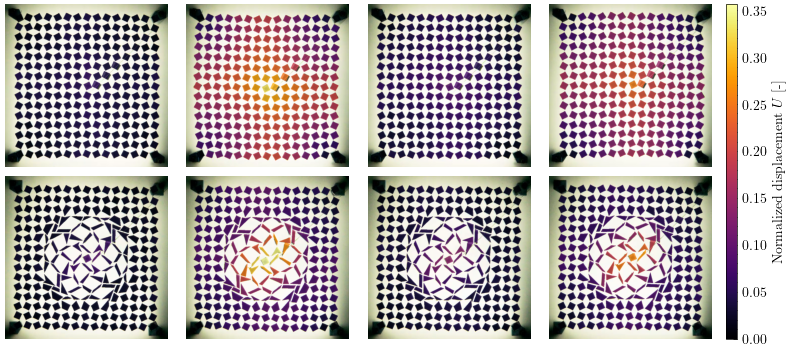

In [20]:
vlim = (
    0,
    selected_experiments.tracked_data.apply(lambda x: jnp.linalg.norm(
        x.fields[:, 0, :, :] * jnp.array([1./problem.spacing, 1./problem.spacing, 1.]), axis=-1).max()).max()
)
plt.close("all")
fig, axes = plt.subplots(ncols=len(selected_timepoints),
                         nrows=selected_experiments.shape[0], figsize=(2*4, 3.5), constrained_layout=True)
for i, row in enumerate(selected_experiments.itertuples()):
    field_values = jnp.linalg.norm(
        row.tracked_data.fields[:, 0, :, :] * jnp.array([1./problem.spacing, 1./problem.spacing, 1.]),
        axis=-1
    )
    for j, time in enumerate(selected_timepoints):
        plot_snapshot_experiment(df_row=row, field="normalized_u", field_values=field_values,
                                 time=time, ax=axes[i, j], vlim=vlim)
# Add colorbar
cmap = plt.cm.inferno
norm = plt.Normalize(vmin=vlim[0], vmax=vlim[1])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cb = fig.colorbar(sm, ax=axes, location="right", label="Normalized displacement $U$ [-]", aspect=30, pad=0.02)
# cb.set_ticks([0])
out_path = out_folder / design_name / f"snapshots_experiment_loading_angle_{selected_experiments.loading_angle.iloc[0]:.0f}deg.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(str(out_path), dpi=300, bbox_inches="tight")

In [ ]:
# # Create horizontal colorbar from vlim[0] to vlim[1]
# cmap = plt.cm.inferno
# norm = plt.Normalize(vmin=vlim[0], vmax=vlim[1])
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
# plt.close("all")
# fig, ax = plt.subplots(figsize=(3.5, 0.67), constrained_layout=True)
# cb = fig.colorbar(sm, ax=ax, cax=ax, orientation="horizontal",
#                   label=r"Normalized displacement $\lVert \boldsymbol{U}\rVert$ [-]", aspect=30)
# # Ticksize 12
# cb.ax.tick_params(labelsize=13)
# # Set colorbar label size to 14
# cb.ax.set_xlabel(r"Normalized displacement $\lVert \boldsymbol{U}\rVert$ [-]", fontsize=15)
# fig.savefig("colorbar.png", dpi=300, bbox_inches="tight")

#### Export all frames: All loading angles side by side

In [42]:
selected_experiments = tracked_data[
    (tracked_data.trial == 1) &
    # (tracked_data.loading_angle == 0.) &
    ((tracked_data.voltage == 70.) | (tracked_data.voltage == 55.))
]
selected_experiments

,label,loading_angle,voltage,frequency,trial,video_path,data
1,reference_shielding_loading_angle_135.0_voltag...,135.0,70.0,2.0,1,../../../data/quads_shielding_multi_loading_so...,"([[-4.116898793059674e-16, 3.0876740947947556e..."
7,reference_shielding_loading_angle_90.0_voltage...,90.0,70.0,2.0,1,../../../data/quads_shielding_multi_loading_so...,"([[-4.116898793059674e-16, 3.0876740947947556e..."
13,reference_shielding_loading_angle_45.0_voltage...,45.0,70.0,2.0,1,../../../data/quads_shielding_multi_loading_so...,"([[-4.116898793059674e-16, 3.0876740947947556e..."
19,reference_shielding_loading_angle_0.0_voltage_...,0.0,70.0,2.0,1,../../../data/quads_shielding_multi_loading_so...,"([[-4.116898793059674e-16, 3.0876740947947556e..."
25,cloaked_shielding_loading_angle_135.0_voltage_...,135.0,55.0,2.0,1,../../../data/quads_shielding_multi_loading_so...,"([[-4.116898793059674e-16, 3.0876740947947556e..."
31,cloaked_shielding_loading_angle_90.0_voltage_5...,90.0,55.0,2.0,1,../../../data/quads_shielding_multi_loading_so...,"([[-4.116898793059674e-16, 3.0876740947947556e..."
37,cloaked_shielding_loading_angle_45.0_voltage_5...,45.0,55.0,2.0,1,../../../data/quads_shielding_multi_loading_so...,"([[-4.116898793059674e-16, 3.0876740947947556e..."
43,cloaked_shielding_loading_angle_0.0_voltage_55...,0.0,55.0,2.0,1,../../../data/quads_shielding_multi_loading_so...,"([[-4.116898793059674e-16, 3.0876740947947556e..."


In [23]:
vlim = (
    0,
    selected_experiments.data.apply(lambda x: jnp.linalg.norm(
        x.fields[:, 0, :, :2], axis=-1).max()).max()
)
times = jnp.linspace(0, 5., 400)
loading_angles_deg = jnp.array([0., 45., 90., 135.])
reference_shielding_tracked_exp = selected_experiments[selected_experiments.label == "reference_shielding"].sort_values(
    "loading_angle")
cloaked_shielding_tracked_exp = selected_experiments[selected_experiments.label == "cloaked_shielding"].sort_values(
    "loading_angle")

# Create a figure with 2 rows
plt.close("all")
fig, axes = plt.subplots(ncols=len(loading_angles_deg),
                         nrows=2, figsize=(2*4, 3.75), constrained_layout=True)
# Add colorbar
cmap = plt.cm.inferno
norm = plt.Normalize(vmin=vlim[0], vmax=vlim[1])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=axes, location="right",
             label="Displacement [mm]", aspect=30, pad=0.02)

plt.ioff()
# Use tqdm to show a progress bar
for time_id, time in tqdm.tqdm(enumerate(times), total=len(times)):
    for i in range(len(loading_angles_deg)):
        # Plot snapshots of the reference design
        plot_snapshot_experiment(
            df_row=reference_shielding_tracked_exp.iloc[i],
            field="u",
            time=time,
            ax=axes[0, i],
            vlim=vlim,
        )
        # Plot snapshots of the cloaked design
        plot_snapshot_experiment(
            df_row=cloaked_shielding_tracked_exp.iloc[i],
            field="u",
            time=time,
            ax=axes[1, i],
            vlim=vlim,
        )
    # Add time label
    rect = patches.Rectangle((5, 5), 210, 45, linewidth=1,
                             edgecolor="black", facecolor="black", alpha=0.8)
    axes[1, 0].add_patch(rect)
    axes[1, 0].text(15, 5, f"$t = {time:.2f}"+"\\,\\text{s}$",
                    fontsize=8, color="white", ha="left", va="bottom")

    out_path = out_folder/design_name/"tracked_exp" / \
        "all_loading_angles_frames"/f"frame_{time_id:04d}.png"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, bbox_inches="tight", dpi=300)
    for ax in axes.flatten():
        ax.clear()
    plt.close(fig)
plt.ion()

100%|██████████| 400/400 [23:31<00:00,  3.53s/it]


### Simulations

#### Snapshots

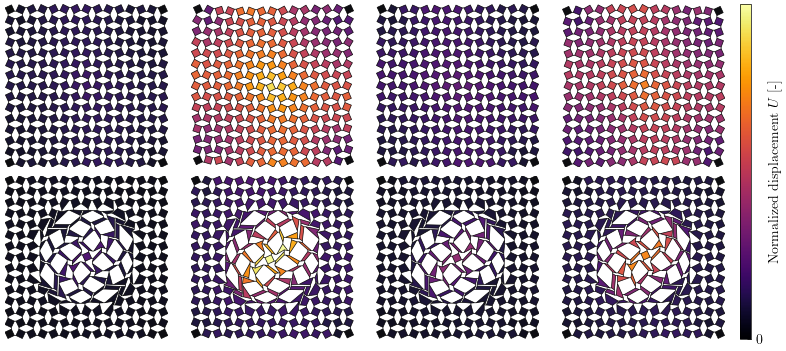

In [54]:
vlim = (
    0,
    selected_experiments.simulation_data.apply(lambda x: jnp.linalg.norm(
        x.fields[:, 0, :, :] * jnp.array([1./problem.spacing, 1./problem.spacing, 1.]), axis=-1).max()).max()
)
plt.close("all")
fig, axes = plt.subplots(ncols=len(selected_timepoints),
                         nrows=selected_experiments.shape[0], figsize=(2*4, 3.5), constrained_layout=True)
for i, row in enumerate(selected_experiments.itertuples()):
    field_values = jnp.linalg.norm(
        row.simulation_data.fields[:, 0, :, :] * jnp.array([1./problem.spacing, 1./problem.spacing, 1.]),
        axis=-1
    )
    for j, time in enumerate(selected_timepoints):
        axes[i, j].set_aspect("equal")
        plot_snapshot_simulation(solution_data=row.simulation_data, field="normalized_u", field_values=field_values,
                                 time=time, ax=axes[i, j], vlim=vlim)
# Add colorbar
cmap = plt.cm.inferno
norm = plt.Normalize(vmin=vlim[0], vmax=vlim[1])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cb = fig.colorbar(sm, ax=axes, location="right", label="Normalized displacement $U$ [-]", aspect=30, pad=0.02)
cb.set_ticks([0])
out_path = out_folder / design_name / f"snapshots_simulation_loading_angle_{selected_experiments.loading_angle.iloc[0]:.0f}deg.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(str(out_path), dpi=300, bbox_inches="tight")

In [30]:
pretrigger_time = 0.  # No pretrigger time for the simulation
loading_rate = 2.  # Hz
selected_timepoints = pretrigger_time + \
    (1+jnp.array([0., 0.25, 0.5, 0.75]))/loading_rate

# NOTE: simulations in problem.solution_data are odered according to loading_angles_deg = jnp.array([0., 45., 90., 135.])
selected_simulations = [problem.solution_data["ig"][1], problem.solution_data["opcg"][1]]

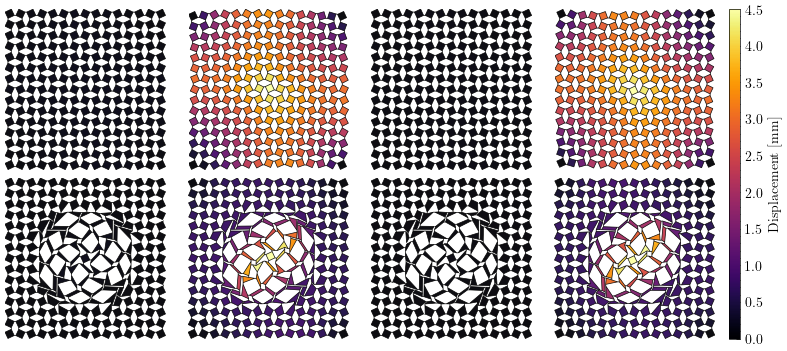

In [ ]:
vlim = (
    0,
    optimization.forward_input.amplitude[0]
)
plt.close("all")
fig, axes = plt.subplots(ncols=len(selected_timepoints), nrows=len(selected_simulations), figsize=(2*4, 3.5), constrained_layout=True)
for i, solution_data in enumerate(selected_simulations):
    for j, time in enumerate(selected_timepoints):
        axes[i, j].set_aspect("equal")
        plot_snapshot_simulation(solution_data=solution_data, field="u", time=time, ax=axes[i, j], vlim=vlim)
# Add colorbar
cmap = plt.cm.inferno
norm = plt.Normalize(vmin=vlim[0], vmax=vlim[1])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=axes, location="right", label="Displacement [mm]", aspect=30, pad=0.02)
# fig.savefig("snapshots_simulation.png", bbox_inches="tight", dpi=300)

### Experiments vs simulations

In [ ]:
plt.close("all")
xlim, ylim = geometry.get_xy_limits(*problem.cloak_to_all_shifts(design_values)) + jnp.array([[-3.5, 3.5],[-3.5, 3.5]])*problem.spacing
fig, axes = plt.subplots(ncols=len(normalized_timepoints), nrows=tracked_data.shape[0]*2, figsize=(2*4, 1.9*4), constrained_layout=True)
for i, row in tracked_data.iterrows():
    for j, time in enumerate(normalized_timepoints):
        plot_snapshot_experiment(
            df_row=row,
            field="theta_abs",
            time=time,
            vlim=(0, 0.4),
            ax=axes[i, j],
        )
        plot_snapshot_simulation(
            solution_data=simulation_data_resampled[i],
            field="theta_abs",
            time=time,
            xlim=xlim,
            ylim=ylim,
            vlim=(0, 0.4),
            ax=axes[2+i, j],
        )
        axes[i, j].axis("equal")
        axes[2+i, j].axis("equal")